# Cuvis Python SDK Example 3
## Load and reprocess a recorded measurement

In this example an already recorded measurement (SessionFile .cu3s) is loaded.
The measurement is reprocessed into different processing modes, explaining their differences.

**Used principles:**
 - *SessionFile* to load a recorded measurement
 - *Measurement* to access the SessionFiles data and meta-data
 - *ProcessingContext* to generate hyperspectral cubes using different processing modes

**Step-by-Step outline:**
 1. Import and initialize Cuvis SDK
 2. Load the recorded measurement file using *SessionFile*
 3. Extract a *Measurement* from the *SessionFile*
 4. Initialize a *ProcessingContext* from a *SessionFile*
 5. Use *ProcessingContext* to generate hyperspectral cubes

**Prerequisites to running this example:**
 - Have a recorded measurement in *SessionFile* format (.cu3s) *or* downloaded the provided [demo data](https://cloud.cubert-gmbh.de/s/SDKSampleData)
 - Have a recorded White and Dark reference measurement *or* use the [demo data](https://cloud.cubert-gmbh.de/s/SDKSampleData)
 - Have the Cuvis SDK installed
 - Have Python and the requirements.txt installed

In [1]:
# If the import of cuvis fails, the most common cause is a mismatch between
# the _cuvis_ python package and the installed version of the Cuvis SDK.
# Try re-installing both and make sure that the version numbers match exactly
import cuvis
import time
from matplotlib import pyplot as plt
import numpy as np
print("Cuvis Python SDK Example 3")

# Initialize the Cuvis SDK using a settings-directory
# This is optional (all settings have defaults),
# but enables you to optimize Cuvis' performance on your system using the settings
# Your camera and the default Cuvis installation both provide these settings files
print("Initializing Cuvis")
cuvis.General.init("./settings")

c:\Users\nima.ghorbani\code-repos\cuvis.python.examples\.venv\Lib\site-packages\cuvis\General.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Cuvis Python SDK Example 3
Initializing Cuvis


In [2]:
# Enter paths applicable to your setup here
session_file_path = "./SDK_Training_Example_Data/WinterUlm_X20P.cu3s"
dark_reference_file_path = session_file_path #"path/to/reference measurement.cu3s"
white_reference_file_path = session_file_path #"path/to/reference measurement.cu3s"

# Load the SessionFile
print(F"Loading Session File '{session_file_path}'")
session = cuvis.SessionFile(session_file_path)
# Fetch the first measurement from the session file
measurement = session.get_measurement(0)

# Load dark reference measurement
print(F"Loading Dark reference file '{dark_reference_file_path}'")
dark_sess = cuvis.SessionFile(dark_reference_file_path)
if (dark_mesu := dark_sess.get_reference(0, cuvis.ReferenceType.Dark)) is not None:
    print("Using Dark reference from Session File") 
else:
    print("Using first measurement as Dark reference") 
    dark_mesu = dark_sess.get_measurement(0)

# Load white reference measurement
print(F"Loading White reference file '{white_reference_file_path}'")
white_sess = cuvis.SessionFile(white_reference_file_path)
if (white_mesu := white_sess.get_reference(0, cuvis.ReferenceType.White)) is not None:
    print("Using White reference from Session File") 
else:
    print("Using first measurement as White reference") 
    white_mesu = white_sess.get_measurement(0)

Loading Session File './SDK_Training_Example_Data/WinterUlm_X20P.cu3s'
Loading Dark reference file './SDK_Training_Example_Data/WinterUlm_X20P.cu3s'
Using Dark reference from Session File
Loading White reference file './SDK_Training_Example_Data/WinterUlm_X20P.cu3s'
Using White reference from Session File


In [3]:
# Helper functions

# Read and print processing mode of the measurement
def print_processing_mode(measurement):
    procmode = measurement.processing_mode
    if procmode == cuvis.ProcessingMode.Preview:
        print("Measurement does not have a hyperspectral cube: Preview Mode")
    elif procmode == cuvis.ProcessingMode.Raw:
        print("Measurement has a hyperspectral cube with raw counts: Raw Mode")
    elif procmode == cuvis.ProcessingMode.DarkSubtract:
        print("Measurement has a hyperspectral cube with raw counts: Dark Subtract Mode")
    elif procmode == cuvis.ProcessingMode.Reflectance:
        print("Measurement has a hyperspectral cube with reflectance values: Reflectance Mode")
    elif procmode == cuvis.ProcessingMode.SpectralRadiance:
        print("Measurement has a hyperspectral cube with Spectral Radiance values: Spectral Radiance Mode")
    else:
        print("Unknown processing mode")

def show_spectrum_and_channel(measurement, i_x=None, i_y=None, i_c=None):
    cube = measurement.cube
    print(F"Cube dimensions: {cube.width} x {cube.height} x {cube.channels}")
    
    x = (cube.width // 2) if i_x is None else i_x
    y = (cube.height // 2) if i_y is None else i_y
    c = (cube.channels // 2) if i_c is None else i_c

    procmode = measurement.processing_mode
    if procmode == cuvis.ProcessingMode.Preview:
        print("Measurement does not have a hyperspectral cube: Preview Mode")
        return
    elif procmode in (cuvis.ProcessingMode.Raw, cuvis.ProcessingMode.DarkSubtract):
        ylabel = "Counts"
    elif procmode == cuvis.ProcessingMode.Reflectance:
        ylabel = "Reflectance [%]"
    elif procmode == cuvis.ProcessingMode.SpectralRadiance:
        ylabel = "Spectral Radiance [W / m² / sr / µm]"
    else:
        print("Unknown processing mode")
        return
    
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    # Spectrum at (x, y)
    spectrum = cube.array[y,x,:]
    if procmode == cuvis.ProcessingMode.Reflectance:
        spectrum = np.array(spectrum, dtype=np.float32)
        spectrum /= 100
    ax0.plot(cube.wavelength, spectrum)
    ax0.set_xlabel("Wavelength")
    ax0.set_ylabel(ylabel)
    ax0.set_title(F"Spectrum at (x={x}, y={y})")
    ax0.grid(True, alpha=0.3)

    # Single channel image
    channel_image = cube.array[:,:,c]
    im = ax1.imshow(channel_image, cmap="gray")
    ax1.set_title(F"Channel {c}")
    fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

    return fig, (ax0, ax1)

In [4]:
print_processing_mode(measurement)

Measurement does not have a hyperspectral cube: Preview Mode


#### Processing Context
The *ProcessingContext* is the interface that enables computing a hyperspectral cube from a measurement.
A camera calibration file is required to initialize the *ProcessingContext*, as each Cubert camera is individually calibrated to provide the most accurate spectral information.
As a SessionFile contains the camera calibration, it is used to construct the *ProcessingContext*.

To generate a hyperspectral cube, the *ProcessingContext* is **applied** to the *Measurement*. The *Measurement* is modified **in-place** and now contains a cube.

To select the processing mode, write the `processing_mode` attribute.

When initializing a *ProcessingContext* from a *SessionFile*, the reference *Measurements* stored in the *SessionFile* are automatically loaded and set within the *ProcessingContext*.
Using the method `set_reference`, different measurements can be set for each reference type.

In [5]:
processing_context = cuvis.ProcessingContext(session)
print("Processing mode is", processing_context.processing_mode)

Processing mode is ProcessingMode.Raw


#### Processing Mode RAW
The mode *RAW* is the most basic processing applied to generate a hyperspectral cube.
No references are necessary for this mode; it also provides the least refined data.
The data is measured in sensor counts, no physical unit can be assigned to this.
The cube data is provided as an integer format.
Either unsigned 8 bit, if the sensor pixel format is Mono8, else unsigned 16 bit.

Measurement has a hyperspectral cube with raw counts: Raw Mode
Cube dimensions: 410 x 410 x 164


(<Figure size 1000x400 with 3 Axes>,
 (<Axes: title={'center': 'Spectrum at (x=205, y=205)'}, xlabel='Wavelength', ylabel='Counts'>,
  <Axes: title={'center': 'Channel 82'}>))

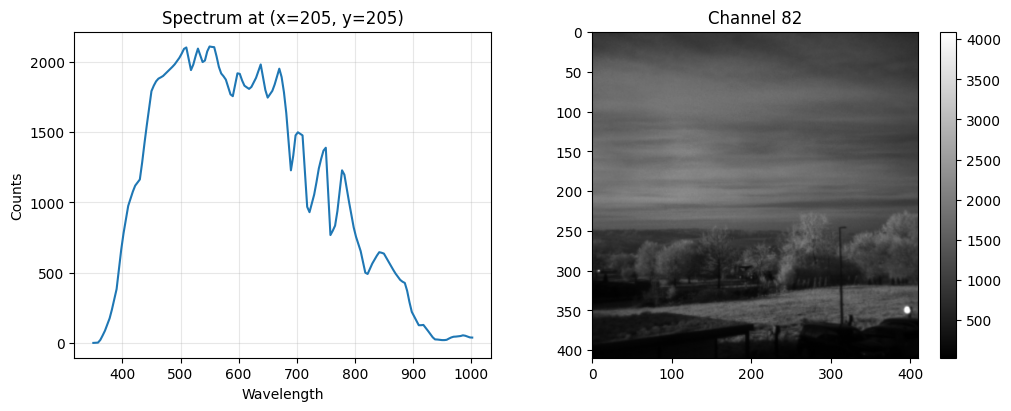

In [6]:
# Set processing mode
processing_context.processing_mode = cuvis.ProcessingMode.Raw

# Compute a cube in Raw mode for the measurement
processing_context.apply(measurement)
# Show data
print_processing_mode(measurement)
# By default shows spectrum of center pixel and channel of center wavelength
show_spectrum_and_channel(measurement) 
# Show custom pixel and channel like this: e.g. pixel at (20, 100) and channel 10
#show_spectrum_and_channel(measurement, i_x=20, i_y=100, i_c=10)

#### Processing Mode Dark Subtract
The mode *Dark Subtract* is similar to *RAW*, as it also measures the data in sensor counts.
A Dark reference is used in the computation for this mode to mitigate the effect of inherent sensor noise, refining the data.

Measurement has a hyperspectral cube with raw counts: Dark Subtract Mode
Cube dimensions: 410 x 410 x 164


(<Figure size 1000x400 with 3 Axes>,
 (<Axes: title={'center': 'Spectrum at (x=205, y=205)'}, xlabel='Wavelength', ylabel='Counts'>,
  <Axes: title={'center': 'Channel 82'}>))

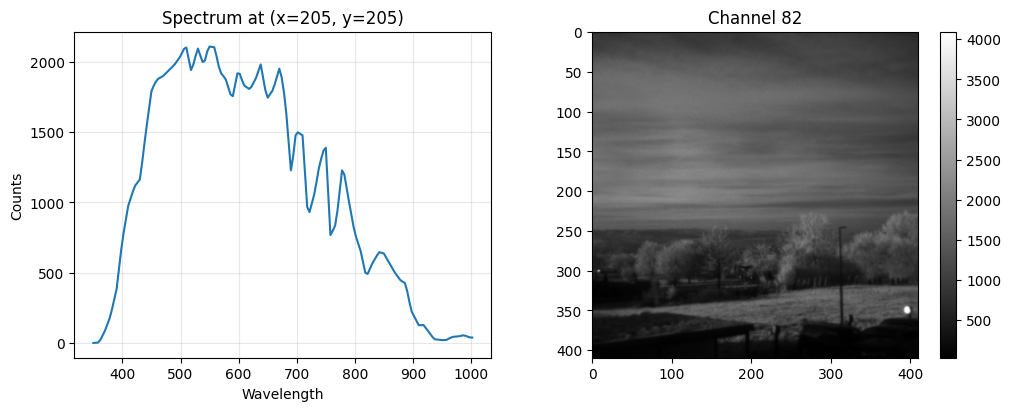

In [7]:
# Set processing mode
processing_context.processing_mode = cuvis.ProcessingMode.DarkSubtract

# Set dark reference
processing_context.set_reference(dark_mesu, cuvis.ReferenceType.Dark)

# Compute a cube in DarkSubtract mode for the measurement
processing_context.apply(measurement)
# Show data
print_processing_mode(measurement)
show_spectrum_and_channel(measurement)

#### Processing Mode Reflectance
The mode *Reflectance* changes how the cube is generated and its data type.
The cube now provides data in the form of reflected light as a percentage.
A Dark and a White reference are used to compute this percentage, ie. 100% reflectance means that the data at this point is as bright as the White reference.

*Please note:*
The cube data are still provided in an integer format (unsigned 16 bit) to speed up processing and reduce storage.
The fixed-point format is defined as such:
 - 0 = 0% Reflectance (as bright as Dark reference)
 - 10000 = 100% Reflectance (as bright as White reference)
 - 30000 = 300% Reflectance (3 times as bright as White reference)
 - 60000 = 600% Reflectance (6 times as bright as White reference)
 - etc.

Measurement has a hyperspectral cube with reflectance values: Reflectance Mode
Cube dimensions: 410 x 410 x 164


(<Figure size 1000x400 with 3 Axes>,
 (<Axes: title={'center': 'Spectrum at (x=205, y=205)'}, xlabel='Wavelength', ylabel='Reflectance [%]'>,
  <Axes: title={'center': 'Channel 82'}>))

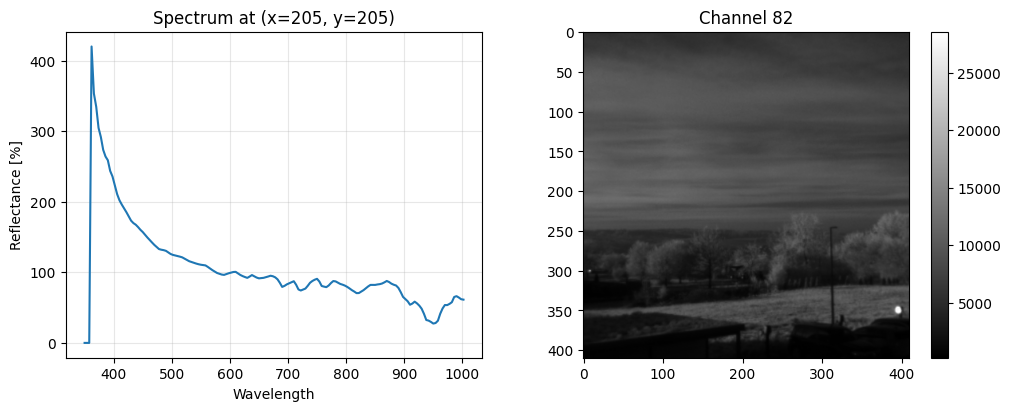

In [8]:
# Set processing mode
processing_context.processing_mode = cuvis.ProcessingMode.Reflectance

# Set references
processing_context.set_reference(dark_mesu, cuvis.ReferenceType.Dark)
processing_context.set_reference(white_mesu, cuvis.ReferenceType.White)

# Compute a cube in Reflectance mode for the measurement
processing_context.apply(measurement)
# Show data
print_processing_mode(measurement)
show_spectrum_and_channel(measurement)

#### Processing Mode Spectral Radiance
The mode *Spectral Radiance* changes how the cube is generated and its data type.
The cube now provides data in the form of a physical unit: W / m² / sr / µm

A Dark reference and a special Spectral Radiance reference are used to compute this.

The Spectral Radiance reference is created by default by Cubert using calibrated measurement equipment during camera build-up and calibration.
It is contained in the camera calibration file.
For older cameras it used to be provided as the file *SpRad.cu3* and may not have been delivered for your camera.

The cube data are provided in a floating point format (float 32 bit).

Measurement has a hyperspectral cube with Spectral Radiance values: Spectral Radiance Mode
Cube dimensions: 410 x 410 x 164


(<Figure size 1000x400 with 3 Axes>,
 (<Axes: title={'center': 'Spectrum at (x=205, y=205)'}, xlabel='Wavelength', ylabel='Spectral Radiance [W / m² / sr / µm]'>,
  <Axes: title={'center': 'Channel 82'}>))

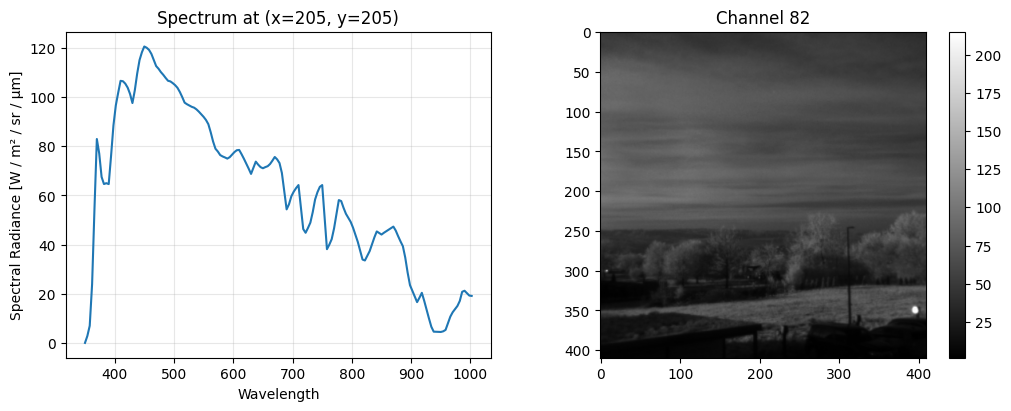

In [9]:
# Set processing mode
processing_context.processing_mode = cuvis.ProcessingMode.SpectralRadiance

# Set dark reference
processing_context.set_reference(dark_mesu, cuvis.ReferenceType.Dark)

# Compute a cube in Spectral Radiance mode for the measurement
processing_context.apply(measurement)
# Show data
print_processing_mode(measurement)
show_spectrum_and_channel(measurement)

#### Distance Calibration
Most Ultris cameras (except for Relay-variants) require distance calibration to achieve optimal results.

**Please note:** The provided default demo dataset was recorded with a relay-equipped camera (Ultris XM with relay optics). Thus this step is not applicable to this dataset.

Distance calibration is an operation that can be done with already recorded data and requires a distance reference measurement.
The reference should contain high-contrast data over the relevant spectral channels at the desired distance that data should be calibrated to.

In this example, the measurement itself will be used as the distance reference. If the target object is suitable (high contrast, non-repeating patterns), this can suffice for good results.

Text(0.5, 1.0, 'With Distance')

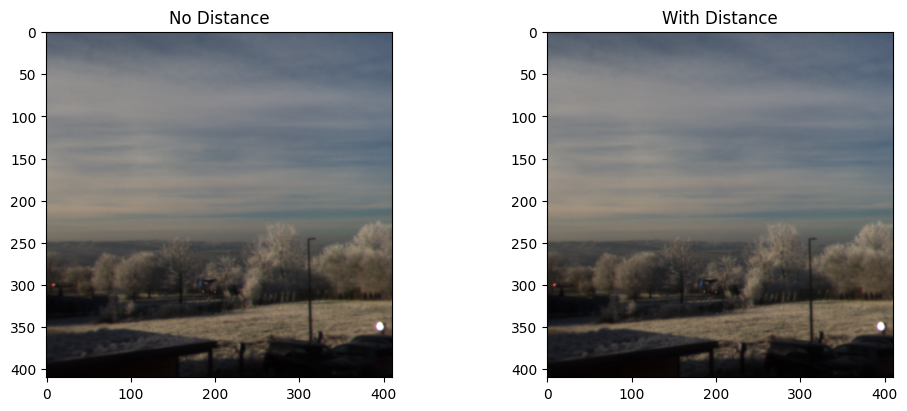

In [12]:
# Set processing mode
processing_context.processing_mode = cuvis.ProcessingMode.Reflectance

# Set references
processing_context.set_reference(dark_mesu, cuvis.ReferenceType.Dark)
processing_context.set_reference(white_mesu, cuvis.ReferenceType.White)
processing_context.clear_reference(cuvis.ReferenceType.Distance)

# Compute a cube in Reflectance mode for the measurement
processing_context.apply(measurement)

# Show data
# Note: The Viewer is explained in detail in Example 5
# It is used here to generate an RGB view of the measurement as
# the effect of Distance calibration is not visible by only observing a single channel
viewer = cuvis.Viewer(cuvis.ViewerSettings(userplugin="./plugins/00_RGB.xml"))
view_nodistance = viewer.apply(measurement)

# Set distance reference
processing_context.set_reference(measurement, cuvis.ReferenceType.Distance)

# Compute a cube in Reflectance mode for the measurement with applied distance
processing_context.apply(measurement)
view_withdistance = viewer.apply(measurement)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ax0.imshow(view_nodistance.array)
ax0.set_title("No Distance")
ax1.imshow(view_withdistance.array)
ax1.set_title("With Distance")

Dropdown(description='Mode:', index=2, options=(('Preview', <ProcessingMode.Preview: 1>), ('Raw', <ProcessingM…

IntSlider(value=82, description='Channel', max=163)

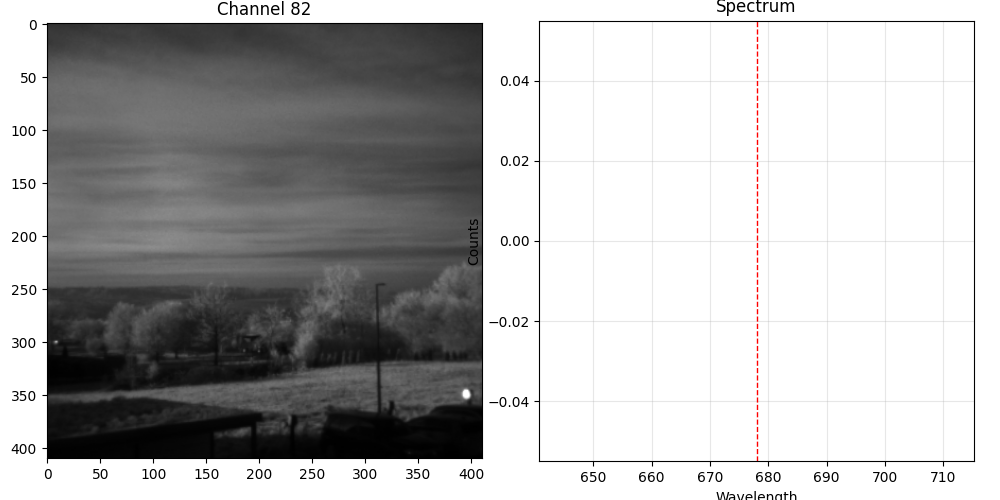

In [13]:
# Interactive visualization of different processing modes
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib widget  

pc = processing_context
# --- Dropdown for selecting processing mode ---
mode_dropdown = widgets.Dropdown(
    options=[
        ("Preview", cuvis.ProcessingMode.Preview),
        ("Raw", cuvis.ProcessingMode.Raw),
        ("DarkSubtract", cuvis.ProcessingMode.DarkSubtract),
        ("Reflectance", cuvis.ProcessingMode.Reflectance),
        ("SpectralRadiance", cuvis.ProcessingMode.SpectralRadiance),
    ],
    value=cuvis.ProcessingMode.Raw,
    description="Mode:",
)

# --- Processing and plotting function ---
def process_and_plot(change=None):
    clear_output(wait=True)
    display(mode_dropdown)

    # Set processing mode from dropdown
    pc.processing_mode = mode_dropdown.value
    pc.apply(measurement)
    cube = measurement.cube

    # --- Plot setup ---
    fig, (ax_img, ax_spec) = plt.subplots(1, 2, figsize=(10, 5))
    plt.tight_layout()

    mid_channel = cube.channels // 2
    im = ax_img.imshow(cube.array[:, :, mid_channel], cmap="gray")
    marker, = ax_img.plot([], [], "r+", markersize=10, markeredgewidth=2)
    ax_img.set_title(f"Channel {mid_channel}")

    (line,) = ax_spec.plot([], [], lw=1.5)
    vline = ax_spec.axvline(cube.wavelength[mid_channel], color="r", ls="--", lw=1)
    ax_spec.set_xlabel("Wavelength")
    ax_spec.set_ylabel("Counts")
    ax_spec.set_title("Spectrum")
    ax_spec.grid(True, alpha=0.3)

    selected_pixel = {"x": None, "y": None}

    # --- Channel slider ---
    channel_slider = widgets.IntSlider(
        value=mid_channel,
        min=0,
        max=cube.channels - 1,
        step=1,
        description="Channel",
        continuous_update=True,
    )

    # --- Click handler ---
    def onclick(event):
        if event.inaxes == ax_img and event.xdata is not None and event.ydata is not None:
            x, y = int(event.xdata), int(event.ydata)
            if 0 <= x < cube.array.shape[1] and 0 <= y < cube.array.shape[0]:
                selected_pixel["x"], selected_pixel["y"] = x, y
                marker.set_data([x], [y])

                spectrum = np.array(cube.array[y, x, :]).ravel()
                wavelengths = np.array(cube.wavelength).ravel()
                line.set_data(wavelengths, spectrum)

                ax_spec.relim()
                ax_spec.autoscale_view()
                ch = channel_slider.value
                vline.set_xdata([cube.wavelength[ch]])
                ax_spec.set_title(
                    f"Spectrum at (x={x}, y={y}) — value={cube.array[y, x, ch]:.3f}"
                )
                fig.canvas.draw_idle()

    fig.canvas.mpl_connect("button_press_event", onclick)

    # --- Slider handler ---
    def on_channel_change(change):
        if change["name"] == "value":
            ch = change["new"]
            im.set_data(cube.array[:, :, ch])
            ax_img.set_title(f"Channel {ch}")
            vline.set_xdata([cube.wavelength[ch]])

            if selected_pixel["x"] is not None:
                x, y = selected_pixel["x"], selected_pixel["y"]
                marker.set_data([x], [y])
                ax_spec.set_title(
                    f"Spectrum at (x={x}, y={y}) — value={cube.array[y, x, ch]:.3f}"
                )
            else:
                marker.set_data([], [])
            fig.canvas.draw_idle()

    channel_slider.observe(on_channel_change, names="value")

    display(channel_slider)
    plt.show()

# --- Link dropdown to processing ---
mode_dropdown.observe(process_and_plot, names="value")

# Display the dropdown for the first time
display(mode_dropdown)
process_and_plot()
